# CNN 심화

In [1]:
import keras

In [2]:
model = keras.models.load_model('best-model.keras')

In [5]:
type(model.layers)

list

In [6]:
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [13]:
conv = model.layers[0]

In [ ]:
conv.weights[0].shape # 가중치 w : 3 * 3 * 1 * 32 = 288, 모델이 필터 크기만큼 학습한 수

TensorShape([3, 3, 1, 32])

In [ ]:
conv.weights[1].shape # 편향 b : 32, 필터 개수만큼 편향 1개

TensorShape([32])

In [22]:
import numpy as np

In [24]:
conv_weights = conv.weights[0].numpy()

In [ ]:
conv_weights.mean(), conv_weights.std()  # 평균, 표준편차

(np.float32(-0.038684476), np.float32(0.26660162))

In [ ]:
# 학습하지 않은 모델 - 구조가 동일함.
no_train_model = keras.Sequential()
no_train_model.add(keras.layers.Input(shape=(28,28,1)))
no_train_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

In [ ]:
# 가중치를 가져옴.
no_train_conv = no_train_model.layers[0]
no_train_weights = no_train_conv.weights[0].numpy()
no_train_weights.mean(), no_train_weights.std()
# 학습 전 후 표준편차를 비교했을 때 -> 표준편차가 학습 후 증가했다.
# 학습 후 필터들이 여러 종류의 패턴을 감지할 수 있는 능력을 가지게 됐다.

(np.float32(-0.0058907922), np.float32(0.080819674))

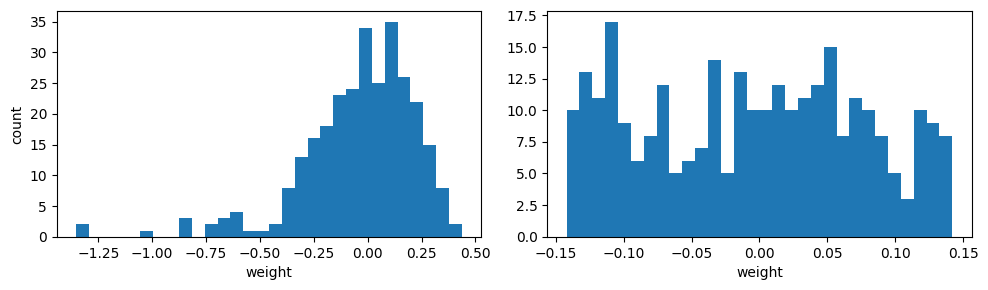

In [32]:
# 학습 전 후 분포 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(conv_weights.reshape(-1), bins=30)
axes[0].set_xlabel('weight'); axes[0].set_ylabel('count')

axes[1].hist(no_train_weights.reshape(-1), bins=30)
axes[1].set_xlabel('weight')

plt.tight_layout(); plt.show()

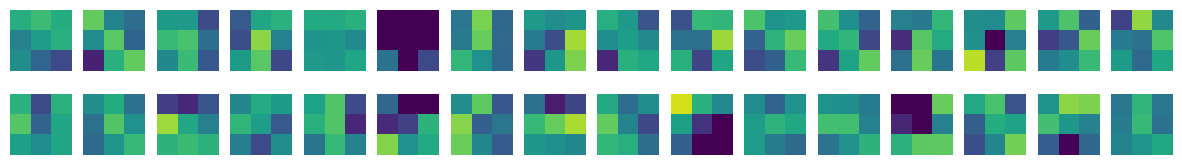

In [ ]:
# 32개의 필터를 그리드로 출력 (학습 후)
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:, :, 0, i*16 + j],
                         vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

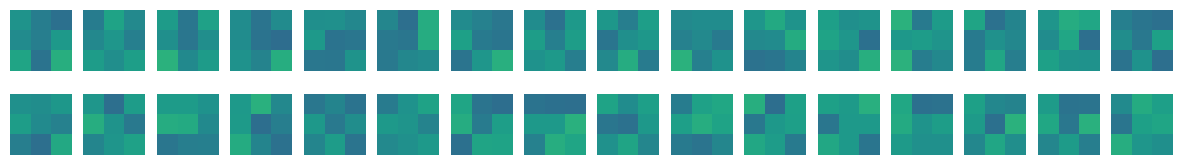

In [34]:
# 32개의 필터를 그리드로 출력 (학습 전)
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_train_weights[:, :, 0, i*16 + j],
                         vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

In [39]:
# 순차적 방식
model_seq = keras.Sequential([
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# 함수형 API
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')

hidden = dense1(inputs)  # 함수 호출하듯이 통과 시킴
outputs = dense2(hidden)

func_model = keras.Model(inputs, outputs)  # 입력 -> 출력 경로 지정하여 모델 완성


In [44]:
model.inputs[0], model.layers[0].output

(<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer>,
 <KerasTensor shape=(None, 28, 28, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor>)

## 특성 맵 비교

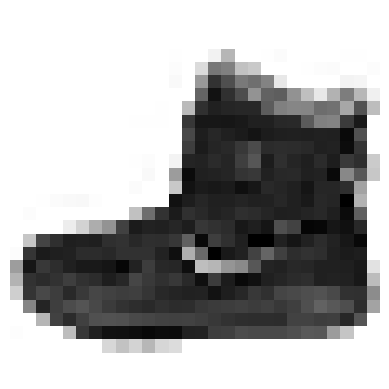

In [46]:
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

plt.imshow(train_input[0], cmap='gray_r')
plt.axis('off')
plt.show()

# 입력값 위해 shape 변경
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1번째 층 출력 크기: (1, 28, 28, 32)


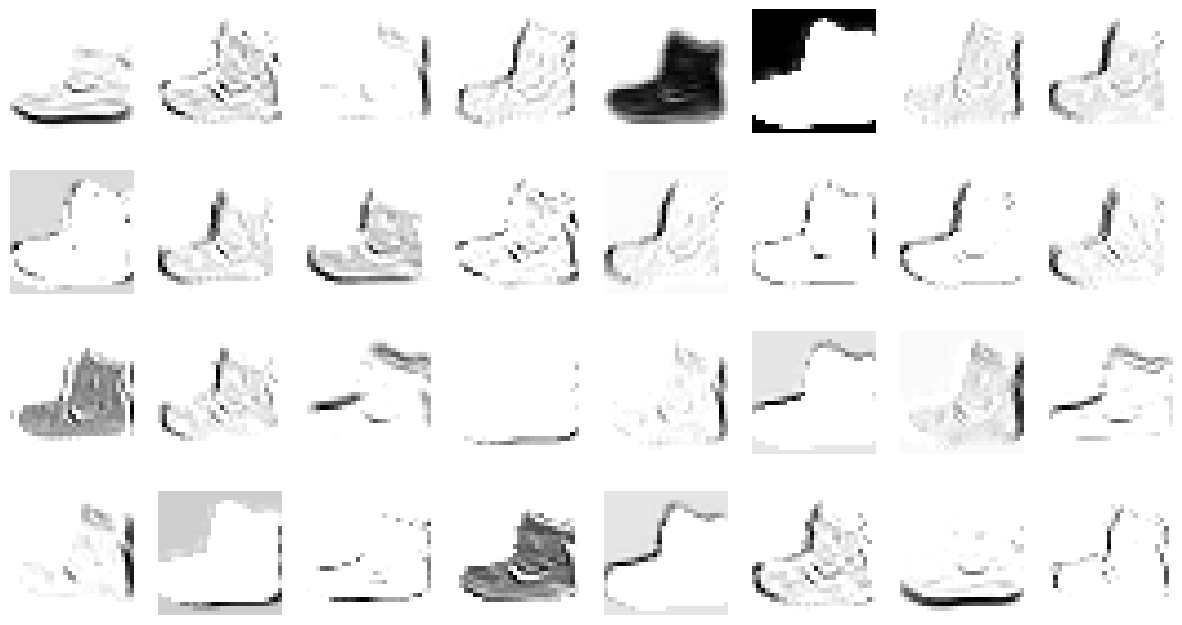

In [47]:
# 2. 1번째 Conv 층 활성화 모델 정의 및 예측
conv1_acti = keras.Model(inputs=model.inputs, outputs=model.layers[0].output)
feature_maps1 = conv1_acti.predict(ankle_boot)

print("1번째 층 출력 크기:", feature_maps1.shape) # (1, 28, 28, 32)

# 3. 4행 8열(32장) 그리드 출력
fig, axs = plt.subplots(4, 8, figsize=(15, 8))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps1[0, :, :, i*8 + j], cmap='gray_r')
        axs[i, j].axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2번째 층 출력 크기: (1, 14, 14, 64)


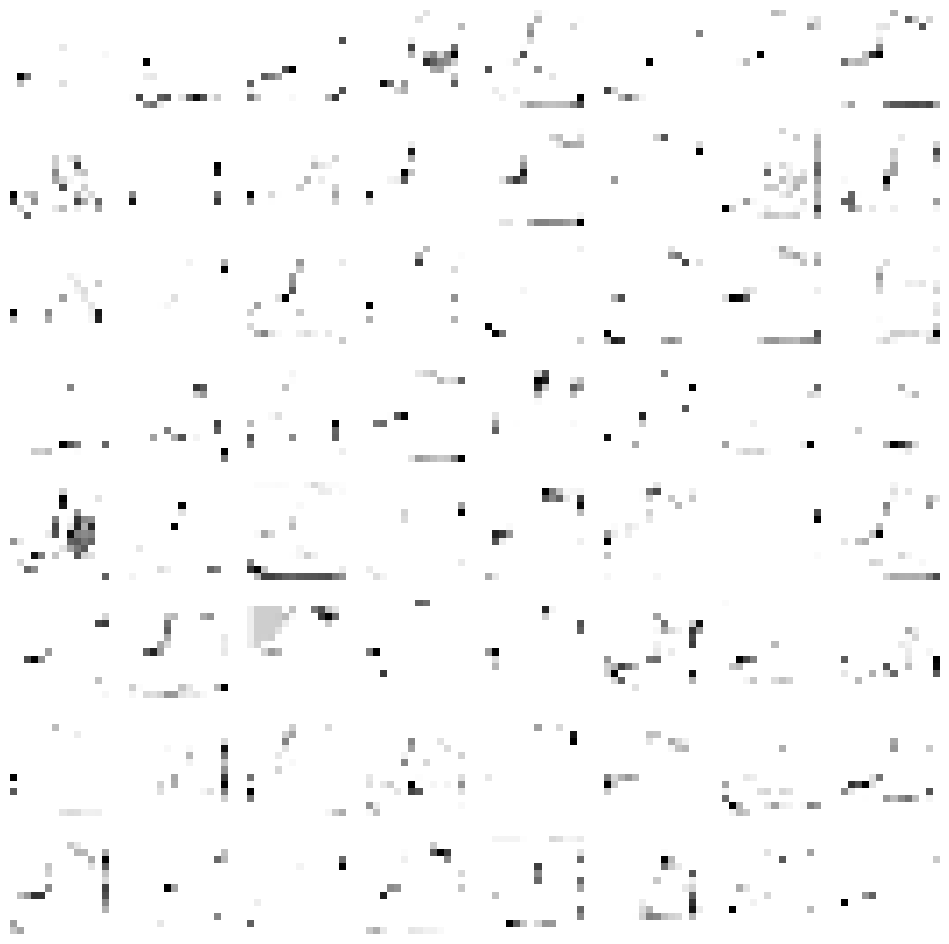

In [48]:
# 1. 2번째 Conv 층 활성화 모델 정의 및 예측 (인덱스 2번은 MaxPooling을 건너뛰기 위함)
conv2_acti = keras.Model(inputs=model.inputs, outputs=model.layers[2].output)
feature_maps2 = conv2_acti.predict(ankle_boot)

print("2번째 층 출력 크기:", feature_maps2.shape) # (1, 14, 14, 64)

# 2. 8행 8열(64장) 그리드 출력
fig, axs = plt.subplots(8, 8, figsize=(12, 12))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps2[0, :, :, i*8 + j], cmap='gray_r')
        axs[i, j].axis('off')
plt.show()

---

## 데이터 증강

In [52]:
# 데이터 증강 : training 때만 사용. 검증, 테스트 때는 사용하지 않음.
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip('horizontal'), # 좌우 대칭
    keras.layers.RandomRotation(0.1),      # 10%를 랜덤하게 회전 36도
    keras.layers.RandomZoom(0.1)           # 10%를 확대하거나 축소
])

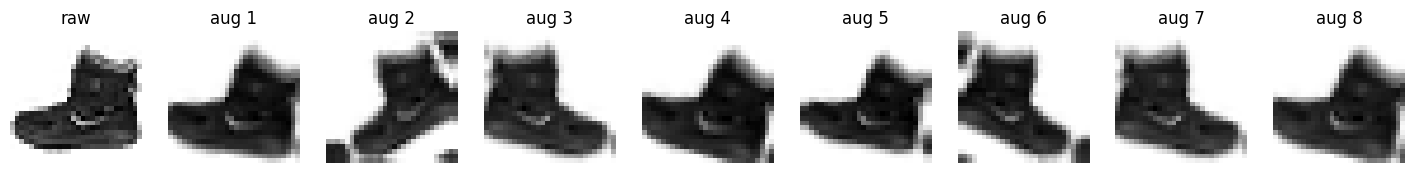

In [54]:
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist

(train_input, _), _ = fashion_mnist.load_data()
sample = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0   # ankle boot 1장

fig, axs = plt.subplots(1, 9, figsize=(18, 2))
axs[0].imshow(sample[0, :, :, 0], cmap='gray_r')
axs[0].set_title("raw")
axs[0].axis('off')

for i in range(1, 9):
    augmented = data_augmentation(sample, training=True)  # training=True: 변형 적용
    axs[i].imshow(augmented[0, :, :, 0], cmap='gray_r')
    axs[i].set_title(f"aug {i}")
    axs[i].axis('off')
plt.show()

In [ ]:
# 증강된 데이터를 모델에 통합
model_aug = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    data_augmentation,                                         # 입력 층 후 증강 층 추가
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation='softmax'),
])

---

# 전이학습

In [55]:
from keras.applications import MobileNetV2

In [57]:
import tensorflow as tf
from keras.datasets import cifar10

# CIFAR-10 로드 (3채널 컬러, 10클래스)
(x_train, y_train_raw), (x_test, y_test_raw) = cifar10.load_data()
y_train = y_train_raw.flatten()   # (50000, 1) → (50000,)
y_test  = y_test_raw.flatten()

# MobileNetV2 최소 입력 크기 96×96 ? CIFAR-10(32×32)을 리사이즈
x_train_r = tf.image.resize(x_train, [96, 96]) / 255.0
x_test_r  = tf.image.resize(x_test,  [96, 96]) / 255.0


In [58]:
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,    # top Dense 제외
    weights="imagenet"    # ImageNet에서 학습된 가중치 사용
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 레이어 갯수, 파라미터 수
len(base_model.layers), base_model.count_params()

(154, 2257984)

In [65]:
# 학습이 가능하게 할 것인가? 
base_model.trainable = False  # 가중치 학습 안 시킴 Freeze. 동결.

In [67]:
inputs = keras.Input((96, 96, 3))   # 입력 층
x = base_model(inputs, training=False) # 학습 안함

In [69]:
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(10, activation='softmax')(x)
model_tl = keras.Model(inputs, x)

In [70]:
model_tl.compile(optimizer='adam', 
                 loss=keras.losses.SparseCategoricalCrossentropy,
                 metrics=['accuracy'])

In [71]:
model_tl.fit(x_test_r, y_train, epochs=5, validation_split=0.2, batch_size=64)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 157ms/step - accuracy: 0.1010 - loss: 2.5866 - val_accuracy: 0.0950 - val_loss: 2.4787
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 148ms/step - accuracy: 0.1305 - loss: 2.3820 - val_accuracy: 0.1000 - val_loss: 2.4790
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.1631 - loss: 2.2958 - val_accuracy: 0.1060 - val_loss: 2.4800
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.1905 - loss: 2.2236 - val_accuracy: 0.1025 - val_loss: 2.4687
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - accuracy: 0.2132 - loss: 2.1716 - val_accuracy: 0.1040 - val_loss: 2.5005


---
## 파인 튜닝

In [72]:
# 1. base_model 일부 해제
base_model.trainable = True

# base_model의 하위 층은 유지, 상위 30층부터 학습 허용
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"전체 레이어: {len(base_model.layers)}")
print(f"동결 레이어: {fine_tune_at}")
print(f"학습 가능 레이어: {len(base_model.layers) - fine_tune_at}")

전체 레이어: 154
동결 레이어: 124
학습 가능 레이어: 30


In [73]:
# 2. 낮은 학습률로 재컴파일 — 기본 Adam LR(1e-3)의 1/10
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model_tl.fit(
    x_train_r, y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 122s 186ms/step - accuracy: 0.7786 - loss: 0.6508 - val_accuracy: 0.7579 - val_loss: 0.6994
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 124s 198ms/step - accuracy: 0.8960 - loss: 0.3063 - val_accuracy: 0.8128 - val_loss: 0.5677
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 200ms/step - accuracy: 0.9440 - loss: 0.1754 - val_accuracy: 0.8451 - val_loss: 0.4732
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 201ms/step - accuracy: 0.9699 - loss: 0.1014 - val_accuracy: 0.8572 - val_loss: 0.4927
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 205ms/step - accuracy: 0.9826 - loss: 0.0646 - val_accuracy: 0.8386 - val_loss: 0.5938
